Aluno: Lucas Barbosa dos Santos

Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_customers_dataset.csv

as tabelas usadas foram:

olist_customers_dataset.csv

olist_order_items_dataset.csv

olist_order_payments_dataset.csv

olist_order_reviews_dataset.csv

olist_orders_dataset.csv

olist_products_dataset.csv

olist_sellers_dataset.csv (apenas na exploração dos dados em Dask)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade "dask[dataframe]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.1 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2025.5.0
    Uninstalling dask-2025.5.0:
      Successfully uninstalled dask-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2025.5.0 requires dask==2025.5.0, but you have dask 2025.9.1 which is incompatible.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.9.1 which is incompatible.


In [ ]:
!pip install --upgrade "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.4 MB/s eta 0:00:00
  Attempting uninstall: distributed
    Found existing installation: distributed 2025.5.0
    Uninstalling distributed-2025.5.0:
      Successfully uninstalled distributed-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.9.1 which is incompatible.
rapids-dask-dependency 25.6.0 requires distributed==2025.5.0, but you have distributed 2025.9.1 which is incompatible.


In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

from dask.distributed import Client, LocalCluster

# Existe integração com pandas, então customização da configuração do pandas também funciona aqui

# Não limitar a largura das colunas apresentadas
pd.options.display.max_colwidth = None
# Não usar a notação científica (ex: 6.125000e-02) e usar 6 casas decimais (ex: 0.061250)
pd.options.display.float_format = "{:.6f}".format
# Não utilizar matplotlib como engine de gráficos e usar plotly
pd.options.plotting.backend = "plotly"

In [ ]:
# Criar cluster local anexado ao kernel do notebook
cluster = LocalCluster()
client = Client(cluster)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:41575
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33693'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35313'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42729 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42729
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:36424
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36659 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36659
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41575,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42729,Total threads: 1
Dashboard: http://127.0.0.1:36577/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:33693,


In [ ]:
#client.close()
#cluster.close()

INFO:distributed.scheduler:Remove client Client-1620b7d0-9d78-11f0-809a-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:36442; closing.
INFO:distributed.scheduler:Remove client Client-1620b7d0-9d78-11f0-809a-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-1620b7d0-9d78-11f0-809a-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1759192094.3153055') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:33693'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:35313'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:36424; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:42729 name: 0 (stimulus_id='handle-worker-cleanup-1759192094.3260977')
INFO:distr

In [4]:
!java --version

openjdk 11.0.28 2025-07-15
OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)


In [5]:
!pip list | grep pyspark

pyspark                               3.5.1


In [6]:
# Remove old Java
!apt-get remove openjdk-* -y

# Install OpenJDK 17
!apt-get update -q
!apt-get install openjdk-17-jdk -y

# Set JAVA_HOME
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Verify
!java -version

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'openjdk-11-jdk' for glob 'openjdk-*'
Note, selecting 'openjdk-11-jre' for glob 'openjdk-*'
Note, selecting 'openjdk-11-jre-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-19-jre-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-8-jre-zero' for glob 'openjdk-*'
Note, selecting 'openjdk-11-jdk-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-21-jdk-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-19-jdk-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-21-demo' for glob 'openjdk-*'
Note, selecting 'openjdk-18-jdk-headless' for glob 'openjdk-*'
Note, selecting 'openjdk-17-dbg' for glob 'openjdk-*'
Note, selecting 'openjdk-17-doc' for glob 'openjdk-*'
Note, selecting 'openjdk-18-dbg' for glob 'openjdk-*'
Note, selecting 'openjdk-17-jdk' for glob 'openjdk-*'
Note, selecting 'openjdk-18-doc' for glob 'openjdk-*'
Note, selecting 'openjdk-17-jre' f

In [7]:
!pip install --upgrade pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.2/434.2 MB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 14.2 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-4.0.1-py2.py3-none-any.whl size=434813800 sha256=a369bfeef4fb4fb00da5f9d52e44b7cb614985ca2d4c6b0f82dc2dd1de4a4f6a
  Stored in directory: /root/.cache/pip/wheels/31/9f/68/f89fb34ccd886909be7d0e390eaaf97f21efdf540c0ee8dbcd
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.7
    Uninstalling py4j-0.10.9.7:
      Successfully uninstalled py4j-0.10.9.7
  Attempting uninstall: pyspark
    Found existing installation: pyspark 3.5.1
    Uninstalling pyspark-3.5.1:
      Successfully uninstalled pyspark-3.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

In [8]:
import pandas as pd
import pyspark.sql.functions as F
import pyspark.sql.types as T

from pyspark.sql import SparkSession

# Não limitar a largura das colunas apresentadas
pd.options.display.max_colwidth = None
# Não usar a notação científica (ex: 6.125000e-02) e usar 6 casas decimais (ex: 0.061250)
pd.options.display.float_format = "{:.6f}".format
# Não utilizar matplotlib como engine de gráficos e usar plotly
pd.options.plotting.backend = "plotly"

In [9]:
# Criando um cluster local com 1 executor e a quantidade de threads igual a quantidade de cores de CPU disponíveis
spark = SparkSession.builder\
  .master("local[*]")\
  .config("spark.executor.memory", "4g")\
  .config("spark.driver.memory", "4g")\
  .getOrCreate()
spark

In [ ]:
# Comando para desativar os recursos do spark
# spark.stop()

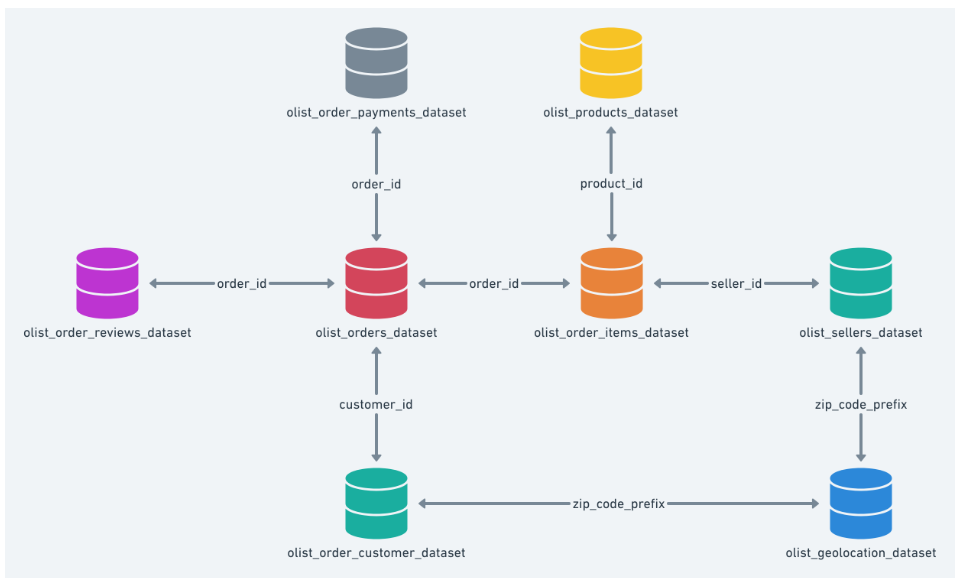

In [10]:
ROOT_DATA_PATH = "drive/MyDrive/data/Brazilian E-Commerce"

#Explorando os Datasets - Dask

In [ ]:
orders_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_orders_dataset.csv")
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
npartitions=1,,,,,,,,
,string,string,string,string,string,string,string,string
,...,...,...,...,...,...,...,...


In [ ]:
%%time

orders_df.head()

CPU times: user 176 ms, sys: 25.8 ms, total: 202 ms
Wall time: 3.31 s


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
%%time

len(orders_df)

CPU times: user 46 ms, sys: 7.23 ms, total: 53.2 ms
Wall time: 611 ms


99441

In [ ]:
orders_df['order_purchase_timestamp'] = dd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = dd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = dd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = dd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = dd.to_datetime(orders_df['order_estimated_delivery_date'])
orders_df


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
npartitions=1,,,,,,,,
,string,string,string,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns]
,...,...,...,...,...,...,...,...


In [ ]:
itens_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_order_items_dataset.csv")
itens_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
npartitions=1,,,,,,,
,string,int64,string,string,string,float64,float64
,...,...,...,...,...,...,...


In [ ]:
%%time

itens_df.head()

CPU times: user 52.1 ms, sys: 2.5 ms, total: 54.6 ms
Wall time: 621 ms


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900000,13.290000
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900000,19.930000
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000000,17.870000
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990000,12.790000
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900000,18.140000


In [ ]:
%%time

len(itens_df)

CPU times: user 40.7 ms, sys: 3.74 ms, total: 44.5 ms
Wall time: 436 ms


112650

In [ ]:
itens_df.isnull().sum().compute()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
payments_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_order_payments_dataset.csv")
payments_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value
npartitions=1,,,,,
,string,int64,string,int64,float64
,...,...,...,...,...


In [ ]:
%%time

payments_df.head()

CPU times: user 30.1 ms, sys: 0 ns, total: 30.1 ms
Wall time: 200 ms


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.330000
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.390000
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.710000
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.780000
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.450000


In [ ]:
%%time

len(payments_df)

CPU times: user 29.8 ms, sys: 2.78 ms, total: 32.6 ms
Wall time: 200 ms


103886

In [ ]:
payments_df.isnull().sum().compute()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
reviews_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_order_reviews_dataset.csv")
reviews_df

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
npartitions=1,,,,,,,
,string,string,int64,string,string,string,string
,...,...,...,...,...,...,...


In [ ]:
%%time

reviews_df.head()

CPU times: user 59.6 ms, sys: 11.4 ms, total: 71 ms
Wall time: 989 ms


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
reviews_df['review_creation_date'] = dd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = dd.to_datetime(reviews_df['review_answer_timestamp'])
reviews_df

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
npartitions=1,,,,,,,
,string,string,float64,string,string,datetime64[ns],datetime64[ns]
,...,...,...,...,...,...,...


In [ ]:
%%time

len(reviews_df)

CPU times: user 54.1 ms, sys: 3.96 ms, total: 58.1 ms
Wall time: 639 ms


99224

In [ ]:
reviews_df.isnull().sum().compute()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
costumers_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_customers_dataset.csv")
costumers_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
npartitions=1,,,,,
,string,string,int64,string,string
,...,...,...,...,...


In [ ]:
%%time

costumers_df.head()

CPU times: user 49.8 ms, sys: 5.42 ms, total: 55.2 ms
Wall time: 722 ms


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
%%time

len(costumers_df)

CPU times: user 37.3 ms, sys: 6.07 ms, total: 43.4 ms
Wall time: 301 ms


99441

In [ ]:
costumers_df.isnull().sum().compute()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
products_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_products_dataset.csv")
products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
npartitions=1,,,,,,,,,
,string,string,int64,int64,int64,int64,int64,int64,int64
,...,...,...,...,...,...,...,...,...


In [ ]:
%%time

products_df.head()

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+----------------------------+---------+----------+
| Column                     | Found   | Expected |
+----------------------------+---------+----------+
| product_description_lenght | float64 | int64    |
| product_height_cm          | float64 | int64    |
| product_length_cm          | float64 | int64    |
| product_name_lenght        | float64 | int64    |
| product_photos_qty         | float64 | int64    |
| product_weight_g           | float64 | int64    |
| product_width_cm           | float64 | int64    |
+----------------------------+---------+----------+

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'product_description_lenght': 'float64',
       'product_height_cm': 'float64',
       'product_length_cm': 'float64',
       'product_name_lenght': 'float64',
       'product_photos_qty': 'float64',
       'product_weight_g': 'float

In [ ]:
products_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_products_dataset.csv",
                          dtype={'product_description_lenght': float,
                                  'product_height_cm': float,
                                  'product_length_cm': float,
                                  'product_name_lenght': float,
                                  'product_photos_qty': float,
                                  'product_weight_g': float,
                                  'product_width_cm': float},
                                    assume_missing=True)
products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
npartitions=1,,,,,,,,,
,string,string,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...


In [ ]:
%%time

products_df.head()

CPU times: user 29.6 ms, sys: 2.46 ms, total: 32 ms
Wall time: 175 ms


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.000000,287.000000,1.000000,225.000000,16.000000,10.000000,14.000000
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.000000,276.000000,1.000000,1000.000000,30.000000,18.000000,20.000000
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.000000,250.000000,1.000000,154.000000,18.000000,9.000000,15.000000
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.000000,261.000000,1.000000,371.000000,26.000000,4.000000,26.000000
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.000000,402.000000,4.000000,625.000000,20.000000,17.000000,13.000000


In [ ]:
%%time

len(products_df)

CPU times: user 18.5 ms, sys: 7.16 ms, total: 25.7 ms
Wall time: 111 ms


32951

In [ ]:
products_df.isnull().sum().compute()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
sellers_df = dd.read_csv(f"{ROOT_DATA_PATH}/olist_sellers_dataset.csv")
sellers_df

,seller_id,seller_zip_code_prefix,seller_city,seller_state
npartitions=1,,,,
,string,int64,string,string
,...,...,...,...


In [ ]:
%%time

sellers_df.head()

CPU times: user 22.5 ms, sys: 0 ns, total: 22.5 ms
Wall time: 58.6 ms


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
%%time

len(sellers_df)

CPU times: user 25.5 ms, sys: 763 µs, total: 26.3 ms
Wall time: 44.6 ms


3095

In [ ]:
sellers_df.isnull().sum().compute()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


#Perguntas - Dask

###1. Qual é o tempo médio de entrega por estado do cliente e quais os 5 estados apresentam mais atrasos em relação à data estimada?

In [ ]:
%%time

merge_orders_costumers_df = orders_df.merge(costumers_df[['customer_id','customer_state']], on='customer_id', how='inner')
merge_orders_costumers_df.head()

CPU times: user 367 ms, sys: 23.9 ms, total: 391 ms
Wall time: 1.69 s


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP


In [ ]:
#tempo médio por estado
merge_orders_costumers_df['average_delivery_time (days)'] = (merge_orders_costumers_df["order_delivered_customer_date"] - merge_orders_costumers_df["order_purchase_timestamp"]).dt.days
merge_orders_costumers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,average_delivery_time (days)
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,2


In [ ]:
merge_orders_costumers_df.groupby('customer_state')\
 ['average_delivery_time (days)']\
 .mean()\
 .rename('days_mean')\
 .reset_index()\
 .sort_values(by=['days_mean'],ascending=True)\
 .compute()

,customer_state,days_mean
25,SP,8.298061
17,PR,11.526711
10,MG,11.543813
6,DF,12.509135
23,SC,14.479560
22,RS,14.819237
18,RJ,14.849186
8,GO,15.150741
11,MS,15.191155
7,ES,15.331830


In [ ]:
# Os 5 estados com mais atrasos
merge_orders_costumers_df[merge_orders_costumers_df['order_delivered_customer_date'] > merge_orders_costumers_df['order_estimated_delivery_date']]\
  .groupby('customer_state')\
  ['order_id']\
  .count()\
  .rename('count_delays')\
  .nlargest(5)\
  .reset_index()\
  .sort_values(by=['count_delays'],ascending=False)\
  .compute()

,customer_state,count_delays
0,SP,2387
1,RJ,1664
2,MG,638
3,BA,457
4,RS,382


###2. Quais categorias de produtos têm o maior ticket médio (valor médio do pedido)?

In [ ]:
ticket_category_df = itens_df.merge(products_df[['product_id','product_category_name']], on='product_id', how='inner')
ticket_category_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900000,13.290000,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900000,19.930000,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000000,17.870000,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990000,12.790000,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900000,18.140000,ferramentas_jardim


In [ ]:
ticket_category_df.groupby('product_category_name')\
  ['price']\
  .mean()\
  .rename('ticket_mean')\
  .nlargest(10)\
  .reset_index()\
  .sort_values(by=['ticket_mean'],ascending=False)\
  .compute()

,product_category_name,ticket_mean
0,pcs,1098.340542
1,portateis_casa_forno_e_cafe,624.285658
2,eletrodomesticos_2,476.124958
3,agro_industria_e_comercio,342.124858
4,instrumentos_musicais,281.616000
5,eletroportateis,280.778468
6,portateis_cozinha_e_preparadores_de_alimentos,264.568667
7,telefonia_fixa,225.693182
8,construcao_ferramentas_seguranca,208.992371
9,relogios_presentes,201.135984


###3. Qual é a distribuição dos meios de pagamento e em quais regiões (estado/UF) há maior uso de parcelas?

In [ ]:
payments_orders_df = payments_df.merge(orders_df[['order_id','customer_id']], on='order_id', how='inner')
payments_orders_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.330000,0a8556ac6be836b46b3e89920d59291c
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.390000,f2c7fc58a9de810828715166c672f10a
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.710000,25b14b69de0b6e184ae6fe2755e478f9
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.780000,7a5d8efaaa1081f800628c30d2b0728f
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.450000,15fd6fb8f8312dbb4674e4518d6fa3b3


In [ ]:
payments_customers_df = payments_orders_df.merge(costumers_df[['customer_id','customer_state']], on='customer_id', how='inner')
payments_customers_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,customer_state
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.330000,0a8556ac6be836b46b3e89920d59291c,MG
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.390000,f2c7fc58a9de810828715166c672f10a,SP
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.710000,25b14b69de0b6e184ae6fe2755e478f9,SP
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.780000,7a5d8efaaa1081f800628c30d2b0728f,MG
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.450000,15fd6fb8f8312dbb4674e4518d6fa3b3,SP


In [ ]:
distribution_df = payments_customers_df.groupby('payment_type')\
['order_id']\
.count()\
.rename('payment_type_count')\
.reset_index()\
.sort_values(by=['payment_type_count'],ascending=False)\
.compute()
distribution_df

,payment_type,payment_type_count
1,credit_card,76795
0,boleto,19784
4,voucher,5775
2,debit_card,1529
3,not_defined,3


In [ ]:
import plotly.express as px

fig = px.pie(
    distribution_df,
    names="payment_type",
    values="payment_type_count",
    title="Distribuição dos Meios de Pagamento"
)

fig.show()

In [ ]:
#Estados com maiores médias de parcelamentos
payments_customers_df[payments_customers_df['payment_installments'] > 1]\
.groupby('customer_state')\
['payment_installments']\
.mean()\
.rename('installments_mean')\
.nlargest(10)\
.reset_index()\
.sort_values(by=['installments_mean'],ascending=False)\
.compute()

,customer_state,installments_mean
0,PB,5.559420
1,SE,5.500000
2,AM,5.320988
3,RO,5.312925
4,RN,5.231013
5,AL,5.225455
6,PI,5.225166
7,AC,5.134615
8,PE,5.134357
9,CE,5.122038


###4. Existe correlação entre avaliação (review score) e tempo de entrega?

In [ ]:
reviews_orders_df = reviews_df.merge(orders_df[['order_id','order_delivered_customer_date', 'order_purchase_timestamp']], on='order_id', how='inner')
reviews_orders_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_delivered_customer_date,order_purchase_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18,2018-01-18 21:46:59,2018-01-17 18:42:41,2018-01-11 15:30:49
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10,2018-03-11 03:05:13,2018-03-09 23:17:20,2018-02-28 12:25:19
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17,2018-02-18 14:36:24,2018-02-16 17:28:48,2018-02-03 09:56:22
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,2017-04-20 09:08:35,2017-04-09 17:41:13
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53,2018-02-28 16:33:35,2018-02-10 10:59:03


In [ ]:
reviews_orders_df['delivery_time(days)'] = (reviews_orders_df['order_delivered_customer_date'] - reviews_orders_df['order_purchase_timestamp']).dt.days
reviews_orders_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_delivered_customer_date,order_purchase_timestamp,delivery_time(days)
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18,2018-01-18 21:46:59,2018-01-17 18:42:41,2018-01-11 15:30:49,6
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10,2018-03-11 03:05:13,2018-03-09 23:17:20,2018-02-28 12:25:19,9
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17,2018-02-18 14:36:24,2018-02-16 17:28:48,2018-02-03 09:56:22,13
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,2017-04-20 09:08:35,2017-04-09 17:41:13,10
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53,2018-02-28 16:33:35,2018-02-10 10:59:03,18


In [ ]:
correlacao = reviews_orders_df[["delivery_time(days)", "review_score"]].corr().compute()
print("Correlação entre tempo de entrega e review_score:")
print(correlacao)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning:

Mean of empty slice.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py:11211: RuntimeWarning:

Degrees of freedom <= 0 for slice

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

invalid value encountered in multiply



Correlação entre tempo de entrega e review_score:
                     delivery_time(days)  review_score
delivery_time(days)             1.000000     -0.333660
review_score                   -0.333660      1.000000


In [ ]:
reviews_orders_df.groupby("review_score")\
 ["delivery_time(days)"]\
 .mean()\
 .rename('delivery_time_mean')\
 .reset_index()\
 .sort_values(by=['delivery_time_mean'],ascending=True)\
 .compute()

,review_score,delivery_time_mean
4,5,10.224097
3,4,11.848054
2,3,13.795278
1,2,16.194832
0,1,20.849825


#Explorando os Datasets - Spark

In [11]:
orders_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_orders_dataset.csv", header=True, inferSchema=True)
orders_df.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b...|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|   delivered|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|          2018-08-07 15:27:45|          2018-08-13 00:00:00|
|47770eb9100c2d0c4...|41ce2a54c0b03bf34...|  

In [12]:
orders_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [13]:
orders_df.count()

99441

In [14]:
itens_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_order_items_dataset.csv", header=True, inferSchema=True)
itens_df.show(5)

+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|            order_id|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1...|            1|4244733e06e7ecb49...|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|
|00018f77f2f0320c5...|            1|e5f2d52b802189ee6...|dd7ddc04e1b6c2c61...|2017-05-03 11:05:13|239.9|        19.93|
|000229ec398224ef6...|            1|c777355d18b72b67a...|5b51032eddd242adc...|2018-01-18 14:48:30|199.0|        17.87|
|00024acbcdf0a6daa...|            1|7634da152a4610f15...|9d7a1d34a50524090...|2018-08-15 10:10:18|12.99|        12.79|
|00042b26cf59d7ce6...|            1|ac6c3623068f30de0...|df560393f3a51e745...|2017-02-13 13:57:51|199.9|        18.14|
+--------------------+-------------+------------

In [15]:
itens_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)



In [16]:
itens_df.count()

112650

In [17]:
payments_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_order_payments_dataset.csv", header=True, inferSchema=True)
payments_df.show(5)

+--------------------+------------------+------------+--------------------+-------------+
|            order_id|payment_sequential|payment_type|payment_installments|payment_value|
+--------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b...|                 1| credit_card|                   8|        99.33|
|a9810da82917af2d9...|                 1| credit_card|                   1|        24.39|
|25e8ea4e93396b6fa...|                 1| credit_card|                   1|        65.71|
|ba78997921bbcdc13...|                 1| credit_card|                   8|       107.78|
|42fdf880ba16b47b5...|                 1| credit_card|                   2|       128.45|
+--------------------+------------------+------------+--------------------+-------------+
only showing top 5 rows


In [18]:
payments_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)



In [19]:
payments_df.count()

103886

In [69]:
reviews_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_order_reviews_dataset.csv", header=True, inferSchema=True)
reviews_df.show(5)

+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+
|           review_id|            order_id|review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|
+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+
|7bc2406110b926393...|73fc7af87114b3971...|           4|                NULL|                  NULL| 2018-01-18 00:00:00|    2018-01-18 21:46:59|
|80e641a11e56f04c1...|a548910a1c6147796...|           5|                NULL|                  NULL| 2018-03-10 00:00:00|    2018-03-11 03:05:13|
|228ce5500dc1d8e02...|f9e4b658b201a9f2e...|           5|                NULL|                  NULL| 2018-02-17 00:00:00|    2018-02-18 14:36:24|
|e64fb393e7b32834b...|658677c97b385a9be...|           5|                NULL|  Recebi bem antes ...| 2017-04-21 00:00:00|   

In [65]:
reviews_df.printSchema()

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)



In [66]:
reviews_df = reviews_df.withColumn(
    "review_creation_date",
    F.to_timestamp("review_creation_date", "yyyy-MM-dd HH:mm:ss")
).withColumn(
    "review_answer_timestamp",
    F.to_timestamp("review_answer_timestamp", "yyyy-MM-dd HH:mm:ss")
)

In [67]:
reviews_df.printSchema()

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: timestamp (nullable = true)
 |-- review_answer_timestamp: timestamp (nullable = true)



In [32]:
reviews_df.count()

104162

In [34]:
customers_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_customers_dataset.csv", header=True, inferSchema=True)
customers_df.show(5)

+--------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------------------+--------------------+--------------+
|06b8999e2fba1a1fb...|861eff4711a542e4b...|                   14409|              franca|            SP|
|18955e83d337fd6b2...|290c77bc529b7ac93...|                    9790|sao bernardo do c...|            SP|
|4e7b3e00288586ebd...|060e732b5b29e8181...|                    1151|           sao paulo|            SP|
|b2b6027bc5c5109e5...|259dac757896d24d7...|                    8775|     mogi das cruzes|            SP|
|4f2d8ab171c80ec83...|345ecd01c38d18a90...|                   13056|            campinas|            SP|
+--------------------+--------------------+------------------------+--------------------+--------------+
only showing top 5 rows


In [35]:
customers_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)



In [36]:
customers_df.count()

99441

In [37]:
products_df = spark.read.csv(f"{ROOT_DATA_PATH}/olist_products_dataset.csv", header=True, inferSchema=True)
products_df.show(5)

+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff454...|           perfumaria|                 40|                       287|                 1|             225|               16|               10|              14|
|3aa071139cb16b67c...|                artes|                 44|                       276|                 1|            1000|               30|               18|              20|
|96bd76ec8810374ed...|        esporte_lazer|                 46|                       250|    

In [38]:
products_df.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)



In [39]:
products_df.count()

32951

#Perguntas - Spark

###1. Qual é o tempo médio de entrega por estado do cliente e quais os 5 estados apresentam mais atrasos em relação à data estimada?

In [40]:
ordes_customers_df = orders_df.join(customers_df, on='customer_id', how='inner')
ordes_customers_df.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|            order_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+
|9ef432eb625129730...|e481f51cbdc54678b...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 

In [42]:
orders_customers_df = ordes_customers_df.withColumn('average_delivery_time(days)',
                                                    F.datediff("order_delivered_customer_date", "order_purchase_timestamp"))
orders_customers_df.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+---------------------------+
|         customer_id|            order_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|average_delivery_time(days)|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+---------------------------+
|9ef432eb625129730...|e481f51cbdc54678b...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07

In [50]:
orders_customers_df.groupBy('customer_state')\
  .mean('average_delivery_time(days)')\
  .withColumnRenamed('avg(average_delivery_time(days))', 'days_mean')\
  .orderBy(F.asc('days_mean'))\
  .toPandas()

,customer_state,days_mean
0,SP,8.700531
1,PR,11.938046
2,MG,11.946543
3,DF,12.899038
4,SC,14.907527
5,RJ,15.237675
6,RS,15.248503
7,GO,15.536025
8,MS,15.544936
9,ES,15.723810


In [51]:
df_delay = orders_customers_df.where(F.col('order_delivered_customer_date') > F.col('order_estimated_delivery_date'))\
.groupBy('customer_state')\
  .count()\
  .withColumnRenamed('count', 'count_delays')\
  .orderBy(F.desc('count_delays'))\
  .limit(5)

df_delay.toPandas()

,customer_state,count_delays
0,SP,2387
1,RJ,1664
2,MG,638
3,BA,457
4,RS,382


###2. Quais categorias de produtos têm o maior ticket médio (valor médio do pedido)?

In [52]:
ticket_category_df = itens_df.join(products_df, on='product_id', how='inner')
ticket_category_df.show(5)

+--------------------+--------------------+-------------+--------------------+-------------------+-----+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|          product_id|            order_id|order_item_id|           seller_id|shipping_limit_date|price|freight_value|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------+--------------------+-------------+--------------------+-------------------+-----+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|4244733e06e7ecb49...|00010242fe8c5a6d1...|            1|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|           cool_stuff|                 58|         

In [53]:
ticket_category_df.groupBy('product_category_name')\
  .mean('price')\
  .withColumnRenamed('avg(price)', 'ticket_mean')\
  .orderBy(F.desc('ticket_mean'))\
  .limit(10)\
  .toPandas()

,product_category_name,ticket_mean
0,pcs,1098.340542
1,portateis_casa_forno_e_cafe,624.285658
2,eletrodomesticos_2,476.124958
3,agro_industria_e_comercio,342.124858
4,instrumentos_musicais,281.616000
5,eletroportateis,280.778468
6,portateis_cozinha_e_preparadores_de_alimentos,264.568667
7,telefonia_fixa,225.693182
8,construcao_ferramentas_seguranca,208.992371
9,relogios_presentes,201.135984


###3. Qual é a distribuição dos meios de pagamento e em quais regiões (estado/UF) há maior uso de parcelas?

In [54]:
payments_orders_df = payments_df.join(orders_df, on='order_id', how='inner')
payments_orders_df.show(5)

+--------------------+------------------+------------+--------------------+-------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|payment_sequential|payment_type|payment_installments|payment_value|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+------------------+------------+--------------------+-------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b...|                 2|     voucher|                   1|        18.59|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13

In [55]:
payments_customers_df = payments_orders_df.join(customers_df, on='customer_id', how='inner')
payments_customers_df.show(5)

+--------------------+--------------------+------------------+------------+--------------------+-------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+-------------+--------------+
|         customer_id|            order_id|payment_sequential|payment_type|payment_installments|payment_value|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|
+--------------------+--------------------+------------------+------------+--------------------+-------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+-------------+--------------+
|

In [59]:
df_plot = payments_customers_df.groupBy('payment_type')\
          .count()\
          .withColumnRenamed('count', 'payment_type_count')\
          .orderBy(F.desc('payment_type_count'))\
          .toPandas()
df_plot

,payment_type,payment_type_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [60]:
import plotly.express as px

fig = px.pie(
    df_plot,
    names="payment_type",
    values="payment_type_count",
    title="Distribuição dos Meios de Pagamento"
)

fig.show()

In [62]:
payments_customers_df.where(F.col('payment_installments') > 1)\
.groupBy('customer_state')\
.mean('payment_installments')\
.withColumnRenamed('avg(payment_installments)', 'installments_mean')\
.orderBy(F.desc('installments_mean'))\
.limit(10)\
.toPandas()

,customer_state,installments_mean
0,PB,5.559420
1,SE,5.500000
2,AM,5.320988
3,RO,5.312925
4,RN,5.231013
5,AL,5.225455
6,PI,5.225166
7,AC,5.134615
8,PE,5.134357
9,CE,5.122038


###4. Existe correlação entre avaliação (review score) e tempo de entrega?

In [70]:
reviews_orders_df = reviews_df.join(orders_df, on='order_id', how='inner')
reviews_orders_df.show(5)

+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|           review_id|review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|00018f77f2f0320c5...|7b07bacd811c4117b...|           4|  

+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------------+
|            order_id|           review_id|review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|delivery_time(days)|
+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------------

In [72]:
reviews_orders_df = reviews_orders_df.withColumn('delivery_time(days)',
                                                    F.datediff("order_delivered_customer_date", "order_purchase_timestamp"))
reviews_orders_df.show(5)

+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------------+
|            order_id|           review_id|review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|delivery_time(days)|
+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------------

In [75]:
reviews_orders_df = reviews_orders_df.withColumn(
    "review_score",
    F.col("review_score").cast("int")
)

# Conferir o schema
reviews_orders_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- review_score: integer (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_time(days): integer (nullable = true)



In [77]:
corr = reviews_orders_df.stat.corr("delivery_time(days)", "review_score")
print("Correlação:", corr)

Correlação: -0.24107032361084413


In [82]:
reviews_orders_df.groupBy('review_score')\
  .mean('delivery_time(days)')\
  .withColumnRenamed('avg(delivery_time(days))', 'delivery_time_mean')\
  .orderBy(F.asc('delivery_time_mean'))\
  .toPandas()

,review_score,delivery_time_mean
0,5,10.625359
1,4,12.253121
2,3,14.204346
3,2,16.605916
4,1,21.251886
